In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

In [184]:
df = pd.read_csv("train.csv")
X_test = pd.read_csv("test.csv")

### Data Preprocessing

In [185]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      6000 non-null   str    
 1   X2      4994 non-null   float64
 2   X3      6000 non-null   str    
 3   X4      6000 non-null   float64
 4   X5      6000 non-null   str    
 5   X6      6000 non-null   float64
 6   X7      6000 non-null   str    
 7   X8      6000 non-null   int64  
 8   X9      4289 non-null   str    
 9   X10     6000 non-null   str    
 10  X11     6000 non-null   str    
 11  Y       6000 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 562.6 KB


In [186]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [187]:
X_test.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11
0,FDO37,NaN,Low Fat,0.021273,Breakfast,229.1326,OUT027,1985,Medium,Tier 3,Supermarket Type3
1,FDV13,17.35,Regular,0.027588,Canned,86.1856,OUT013,1987,High,Tier 3,Supermarket Type1
2,FDF52,9.30,Low Fat,0.111782,Frozen Foods,182.3292,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDY11,6.71,Regular,0.029606,Baking Goods,65.4142,OUT049,1999,Medium,Tier 1,Supermarket Type1
4,FDL20,17.10,Low Fat,0.129141,Fruits and Vegetables,109.4886,OUT017,2007,NaN,Tier 2,Supermarket Type1


In [188]:
df["X1"].unique()

<StringArray>
['FDA15', 'DRC01', 'FDN15', 'FDX07', 'NCD19', 'FDP36', 'FDO10', 'FDP10',
 'FDH17', 'FDU28',
 ...
 'FDN40', 'NCV18', 'FDP15', 'NCD55', 'DRG25', 'FDN51', 'FDB46', 'NCX17',
 'FDH31', 'FDX13']
Length: 1553, dtype: str

In [189]:
df = df.drop(columns=['X1'])

In [190]:
X_test = X_test.drop(columns=["X1"])

In [191]:
df.head()

,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,Y
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [192]:
df.duplicated().sum()

np.int64(0)

In [193]:
X_test.duplicated().sum()

np.int64(0)

In [194]:
df.shape

(6000, 11)

In [195]:
def full_info(df, top_values=5, show_nulls=True):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "non_null_count": df.notnull().sum(),
        "null_count": df.isnull().sum(),
        "unique_values": df.nunique(),
        "example_values": df.apply(lambda x: x.dropna().unique()[:top_values])
    })

    print("=== DataFrame Info ===")
    print(f"Rows: {df.shape[0]}, Features: {df.shape[1]}")
    print("\n=== Features Summary ===")
    return summary

In [196]:
full_info(df)

=== DataFrame Info ===
Rows: 6000, Features: 11

=== Features Summary ===


,dtype,non_null_count,null_count,unique_values,example_values
X2,float64,4994,1006,410,"[9.3, 5.92, 17.5, 19.2, 8.93]"
X3,str,6000,0,5,"[Low Fat, Regular, low fat, LF, reg]"
X4,float64,6000,0,5577,"[0.016047301, 0.019278216, 0.016760075, 0.0, 0..."
X5,str,6000,0,16,"[Dairy, Soft Drinks, Meat, Fruits and Vegetabl..."
X6,float64,6000,0,4634,"[249.8092, 48.2692, 141.618, 182.095, 53.8614]"
X7,str,6000,0,10,"[OUT049, OUT018, OUT010, OUT013, OUT027]"
X8,int64,6000,0,9,"[1999, 2009, 1998, 1987, 1985]"
X9,str,4289,1711,3,"[Medium, High, Small]"
X10,str,6000,0,3,"[Tier 1, Tier 3, Tier 2]"
X11,str,6000,0,4,"[Supermarket Type1, Supermarket Type2, Grocery..."


In [197]:
df["X5"].value_counts()

X5
Fruits and Vegetables    875
Snack Foods              840
Household                643
Frozen Foods             621
Dairy                    487
Canned                   455
Baking Goods             454
Health and Hygiene       342
Soft Drinks              311
Meat                     294
Breads                   182
Hard Drinks              150
Others                   117
Starchy Foods            108
Breakfast                 75
Seafood                   46
Name: count, dtype: int64

In [198]:
df["X5"].unique()

<StringArray>
[                'Dairy',           'Soft Drinks',                  'Meat',
 'Fruits and Vegetables',             'Household',          'Baking Goods',
           'Snack Foods',          'Frozen Foods',             'Breakfast',
    'Health and Hygiene',           'Hard Drinks',                'Canned',
                'Breads',         'Starchy Foods',                'Others',
               'Seafood']
Length: 16, dtype: str

In [199]:
df['X5']

0                       Dairy
1                 Soft Drinks
2                        Meat
3       Fruits and Vegetables
4                   Household
                ...          
5995    Fruits and Vegetables
5996             Frozen Foods
5997    Fruits and Vegetables
5998             Baking Goods
5999                Household
Name: X5, Length: 6000, dtype: str

In [200]:
df['X5'].value_counts()

X5
Fruits and Vegetables    875
Snack Foods              840
Household                643
Frozen Foods             621
Dairy                    487
Canned                   455
Baking Goods             454
Health and Hygiene       342
Soft Drinks              311
Meat                     294
Breads                   182
Hard Drinks              150
Others                   117
Starchy Foods            108
Breakfast                 75
Seafood                   46
Name: count, dtype: int64

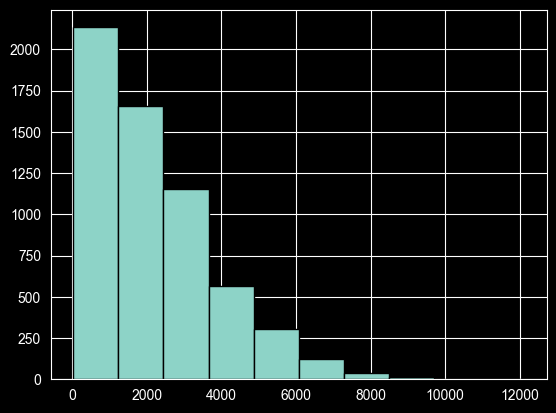

In [201]:
plt.hist(df["Y"], edgecolor = 'k')
plt.show()

#### Handling Nans

In [202]:
df.isnull().sum()

X2     1006
X3        0
X4        0
X5        0
X6        0
X7        0
X8        0
X9     1711
X10       0
X11       0
Y         0
dtype: int64

In [203]:
X_test.isnull().sum()

X2     457
X3       0
X4       0
X5       0
X6       0
X7       0
X8       0
X9     699
X10      0
X11      0
dtype: int64

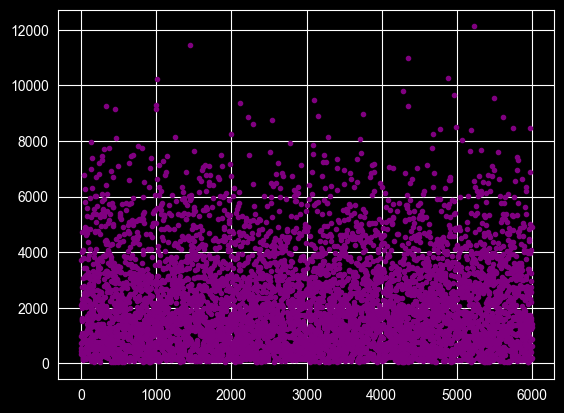

In [204]:
plt.scatter(df.index, df["Y"],marker='.', color ='purple')
plt.show()

In [205]:
df['X9'] = df['X9'].fillna(df['X9'].mode()[0])
X_test['X9'] = X_test['X9'].fillna(df['X9'].mode()[0])

In [206]:
df.isnull().sum()

X2     1006
X3        0
X4        0
X5        0
X6        0
X7        0
X8        0
X9        0
X10       0
X11       0
Y         0
dtype: int64

In [207]:
X_test.isnull().sum()

X2     457
X3       0
X4       0
X5       0
X6       0
X7       0
X8       0
X9       0
X10      0
X11      0
dtype: int64

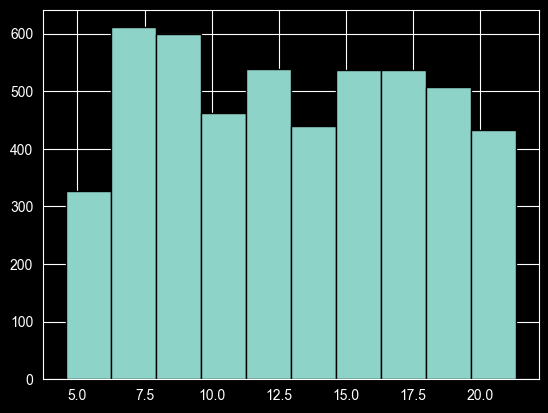

In [208]:
plt.hist(df['X2'], edgecolor='k')
plt.show()

In [209]:
df['X2'] = df['X2'].fillna(df['X2'].mean())

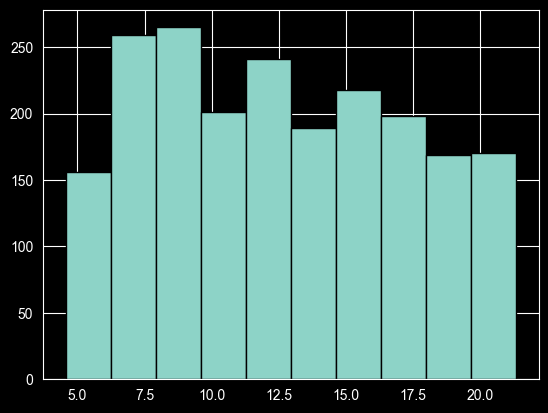

In [210]:
plt.hist(X_test['X2'], edgecolor='k')
plt.show()

In [211]:
X_test['X2'] = X_test['X2'].fillna(X_test['X2'].mean())

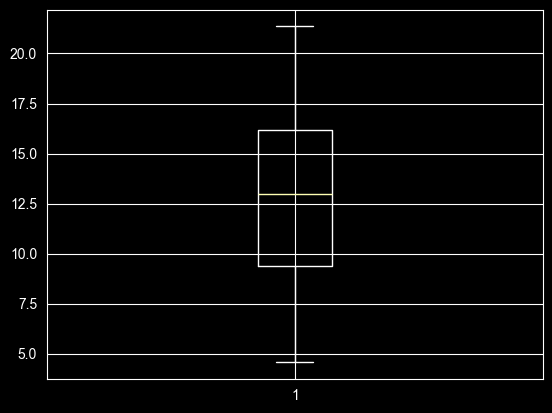

In [212]:
plt.boxplot(df['X2'])
plt.show()

#### Handling Outliers

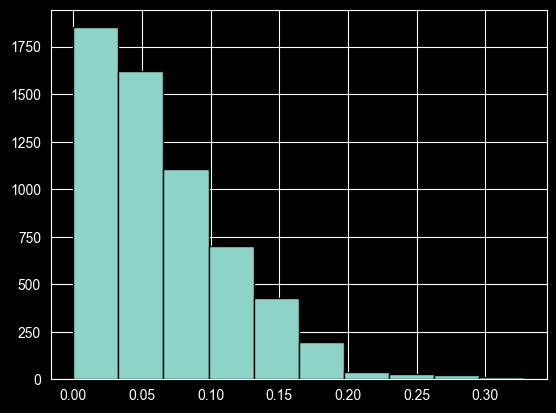

In [213]:
plt.hist(df['X4'], edgecolor='k')
plt.show()

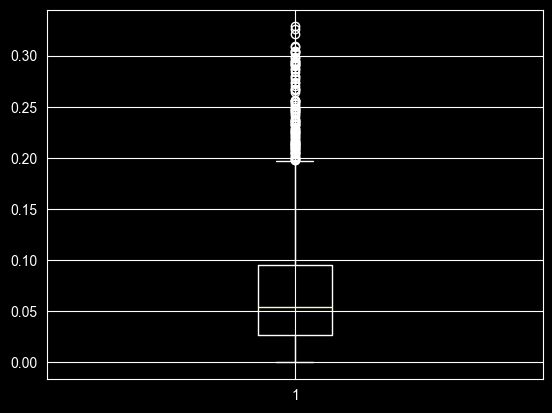

In [214]:
plt.boxplot(df['X4'])
plt.show()

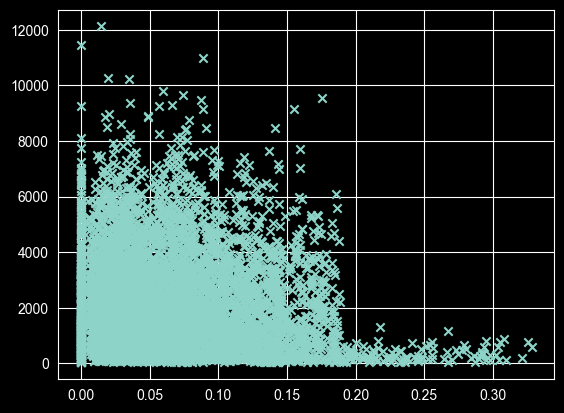

In [215]:
plt.scatter(df['X4'], df['Y'], marker='x')
plt.show()

In [216]:
df['X4'].unique()

array([0.0160473 , 0.01927822, 0.01676007, ..., 0.11506426, 0.05790955,
       0.05492015], shape=(5577,))

In [217]:
df['X4'].max()

np.float64(0.328390948)

In [218]:
q3 = df['X4'].quantile(0.75)
q1 = df['X4'].quantile(0.25)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

df["X4"] = df["X4"].clip(upper=upper_bound, lower=lower_bound)

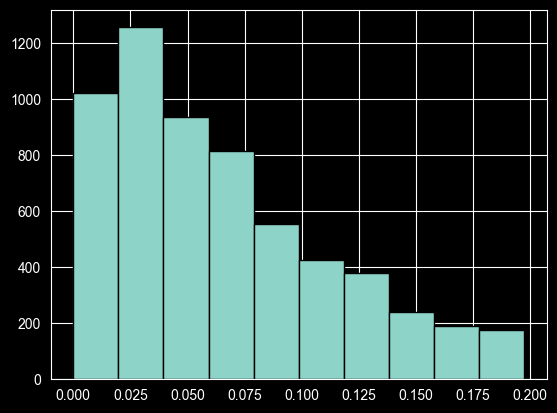

In [219]:
plt.hist(df['X4'], edgecolor='k')
plt.show()

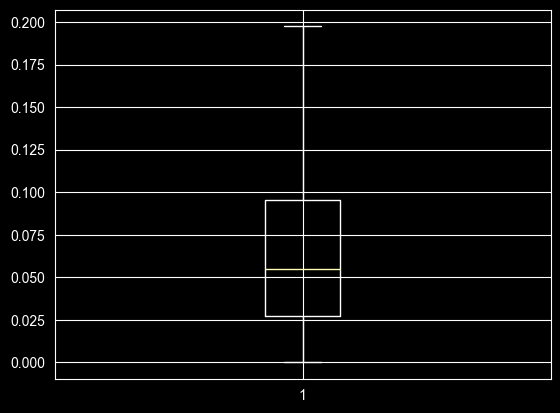

In [220]:
plt.boxplot(df['X4'])
plt.show()

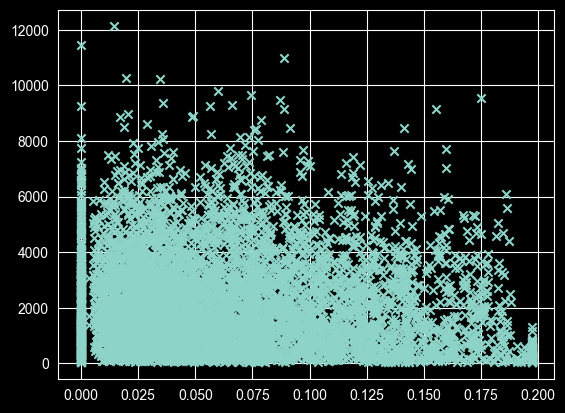

In [221]:
plt.scatter(df['X4'], df['Y'], marker='x')
plt.show()

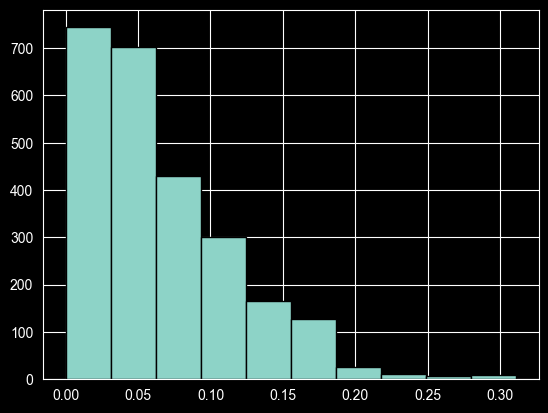

In [222]:
plt.hist(X_test['X4'], edgecolor='k')
plt.show()

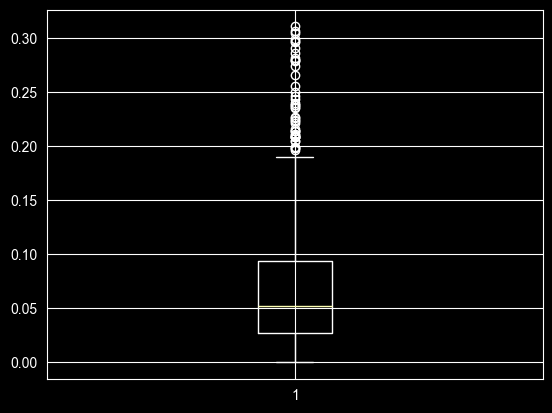

In [223]:
plt.boxplot(X_test['X4'])
plt.show()

In [224]:
X_test["X4"] = X_test["X4"].clip(upper=upper_bound, lower=lower_bound)

In [225]:
df['X4'].value_counts()

X4
0.000000    360
0.197340     97
0.076975      3
0.071958      2
0.074613      2
           ... 
0.190711      1
0.023586      1
0.115064      1
0.057910      1
0.054920      1
Name: count, Length: 5481, dtype: int64

#### Feature Engineering

In [226]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

df['type_mean_sales'] = np.nan
df['category_mean_sales'] = np.nan

for train_idx, val_idx in kf.split(df):

    train_fold = df.iloc[train_idx]
    val_fold = df.iloc[val_idx]

    # compute means ONLY on training fold
    type_means = train_fold.groupby('X11')['Y'].mean()
    category_means = train_fold.groupby('X5')['Y'].mean()

    # map to validation fold
    df.loc[df.index[val_idx], 'type_mean_sales'] = \
        df.loc[df.index[val_idx], 'X11'].map(type_means)

    df.loc[df.index[val_idx], 'category_mean_sales'] = \
        df.loc[df.index[val_idx], 'X5'].map(category_means)


In [227]:
final_type_means = df.groupby('X11')['Y'].mean()
final_category_means = df.groupby('X5')['Y'].mean()

X_test['type_mean_sales'] = X_test['X11'].map(final_type_means)
X_test['category_mean_sales'] = X_test['X5'].map(final_category_means)


#### Feature Visualizations & Relations

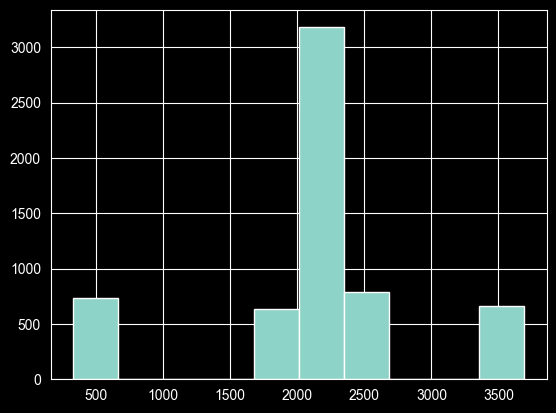

In [228]:
plt.hist(df['type_mean_sales'])
plt.show()

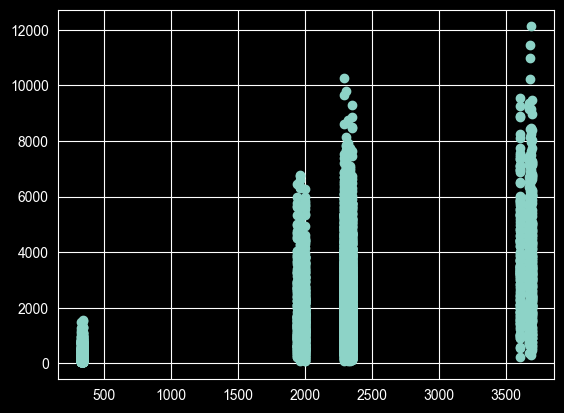

In [229]:
plt.scatter(df['type_mean_sales'], df['Y'])
plt.show()

In [230]:
df['type_mean_sales'].value_counts()

type_mean_sales
2292.769116    815
2323.336500    796
2304.929516    794
2350.297024    786
2337.872719    776
328.740182     156
342.849378     153
3676.326104    151
340.458189     149
339.932513     145
3691.914776    139
2002.946554    138
3604.799663    138
339.161612     134
2002.159677    133
1942.692996    129
1961.362930    121
3672.857342    119
1965.341922    116
3682.589705    112
Name: count, dtype: int64

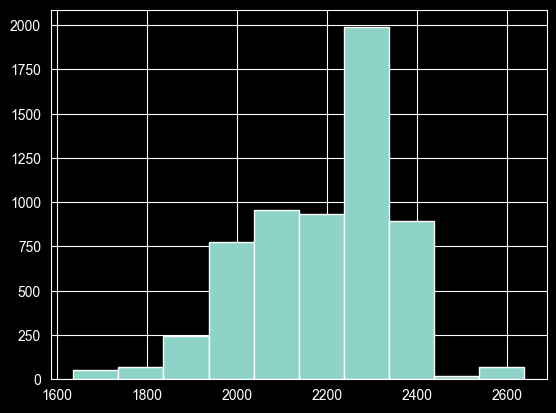

In [231]:
plt.hist(df['category_mean_sales'])
plt.show()

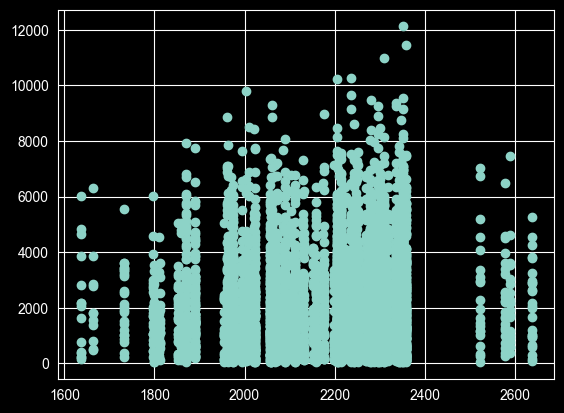

In [232]:
plt.scatter(df['category_mean_sales'], df['Y'])
plt.show()

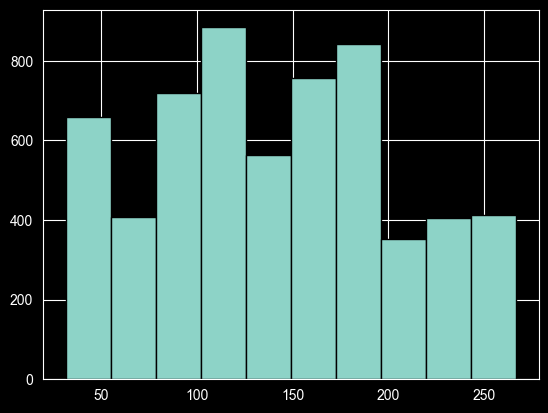

In [233]:
plt.hist(df['X6'], edgecolor='k')
plt.show()

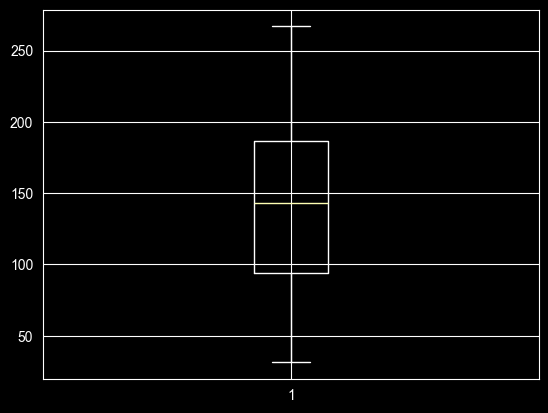

In [234]:
plt.boxplot(df['X6'])
plt.show()

In [235]:
df['X7'].unique()

<StringArray>
['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045', 'OUT017',
 'OUT046', 'OUT035', 'OUT019']
Length: 10, dtype: str

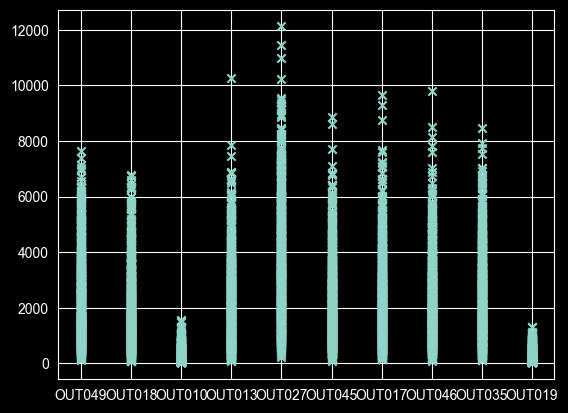

In [236]:
plt.scatter(df['X7'], df['Y'], marker='x')
plt.show()

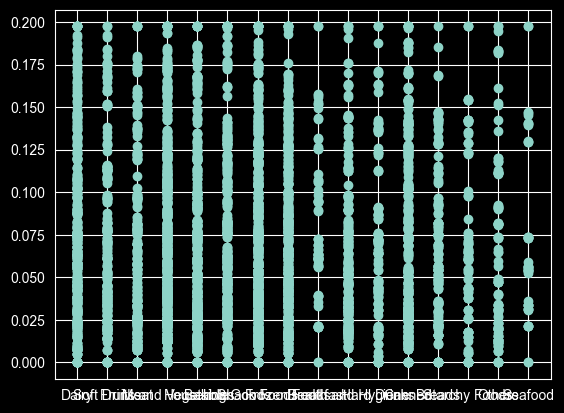

In [237]:
plt.scatter(df['X5'], df['X4'])
plt.show()

In [238]:
df["X3"].unique()

<StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [239]:
full_info(df)

=== DataFrame Info ===
Rows: 6000, Features: 13

=== Features Summary ===


,dtype,non_null_count,null_count,unique_values,example_values
X2,float64,6000,0,411,"[9.3, 5.92, 17.5, 19.2, 8.93]"
X3,str,6000,0,5,"[Low Fat, Regular, low fat, LF, reg]"
X4,float64,6000,0,5481,"[0.016047301, 0.019278216, 0.016760075, 0.0, 0..."
X5,str,6000,0,16,"[Dairy, Soft Drinks, Meat, Fruits and Vegetabl..."
X6,float64,6000,0,4634,"[249.8092, 48.2692, 141.618, 182.095, 53.8614]"
X7,str,6000,0,10,"[OUT049, OUT018, OUT010, OUT013, OUT027]"
X8,int64,6000,0,9,"[1999, 2009, 1998, 1987, 1985]"
X9,str,6000,0,3,"[Medium, High, Small]"
X10,str,6000,0,3,"[Tier 1, Tier 3, Tier 2]"
X11,str,6000,0,4,"[Supermarket Type1, Supermarket Type2, Grocery..."


In [240]:
df["X11"].value_counts()

X11
Supermarket Type1    3967
Grocery Store         737
Supermarket Type3     659
Supermarket Type2     637
Name: count, dtype: int64

In [241]:
df["X5"].value_counts()

X5
Fruits and Vegetables    875
Snack Foods              840
Household                643
Frozen Foods             621
Dairy                    487
Canned                   455
Baking Goods             454
Health and Hygiene       342
Soft Drinks              311
Meat                     294
Breads                   182
Hard Drinks              150
Others                   117
Starchy Foods            108
Breakfast                 75
Seafood                   46
Name: count, dtype: int64

In [242]:
full_info(X_test)

=== DataFrame Info ===
Rows: 2523, Features: 12

=== Features Summary ===


,dtype,non_null_count,null_count,unique_values,example_values
X2,float64,2523,0,369,"[12.618603581800581, 17.35, 9.3, 6.71, 17.1]"
X3,str,2523,0,5,"[Low Fat, Regular, LF, low fat, reg]"
X4,float64,2523,0,2306,"[0.021273161, 0.02758789, 0.11178154, 0.029606..."
X5,str,2523,0,16,"[Breakfast, Canned, Frozen Foods, Baking Goods..."
X6,float64,2523,0,2246,"[229.1326, 86.1856, 182.3292, 65.4142, 109.4886]"
X7,str,2523,0,10,"[OUT027, OUT013, OUT010, OUT049, OUT017]"
X8,int64,2523,0,9,"[1985, 1987, 1998, 1999, 2007]"
X9,str,2523,0,3,"[Medium, High, Small]"
X10,str,2523,0,3,"[Tier 3, Tier 1, Tier 2]"
X11,str,2523,0,4,"[Supermarket Type3, Supermarket Type1, Grocery..."


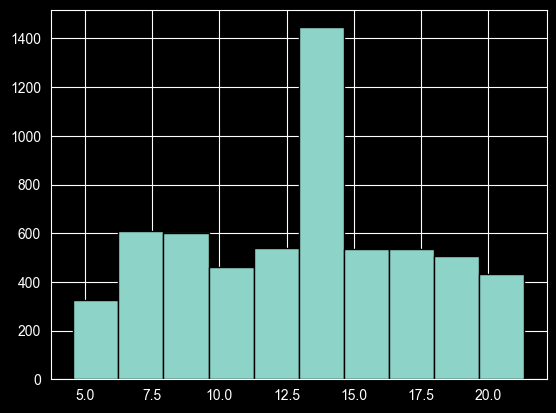

In [243]:
plt.hist(df['X2'], edgecolor='k')
plt.show()

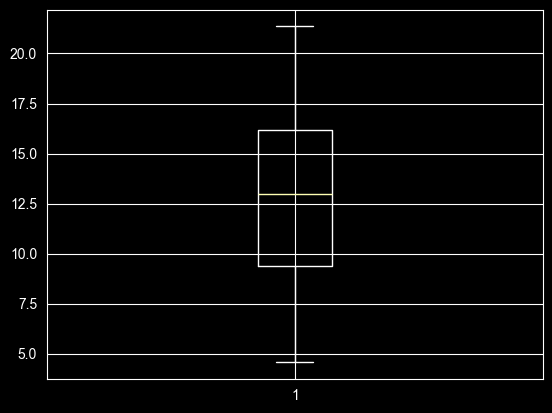

In [244]:
plt.boxplot(df['X2'])
plt.show()

#### Encoding Categorical Features

In [245]:
df["X3"].unique()

<StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [246]:
df["X3"] = df["X3"].map({'Low Fat':0, 'low fat':0, 'LF':0, 'Regular':1, 'reg':1})
X_test["X3"] = X_test["X3"].map({'Low Fat':0, 'low fat':0, 'LF':0, 'Regular':1, 'reg':1})

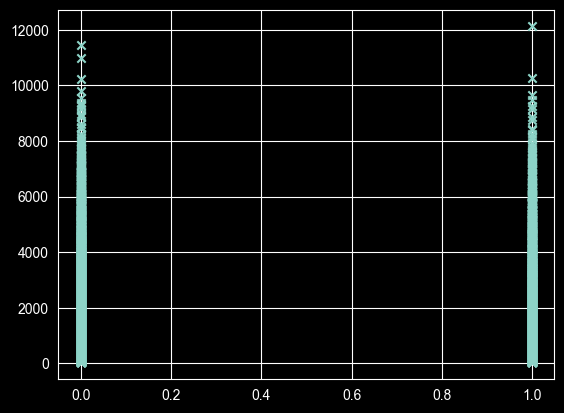

In [247]:
plt.scatter(df['X3'], df['Y'], marker='x')
plt.show()

In [248]:
print(df['X9'].unique() ,'\n',df['X10'].unique())

<StringArray>
['Medium', 'High', 'Small']
Length: 3, dtype: str 
 <StringArray>
['Tier 1', 'Tier 3', 'Tier 2']
Length: 3, dtype: str


In [249]:
df["X9"] = df['X9'].map({'Small':0,'Medium':1, 'High':2})
X_test["X9"] = X_test['X9'].map({'Small':0,'Medium':1, 'High':2})

In [250]:
df["X10"] = df['X10'].map({'Tier 1':0,'Tier 2':1, 'Tier 3':2})
X_test["X10"] = X_test['X10'].map({'Tier 1':0,'Tier 2':1, 'Tier 3':2})

In [251]:
from sklearn.preprocessing import LabelEncoder
cols = ["X5", "X11", 'X7']
for i in cols:
  le = LabelEncoder()
  df[i] = le.fit_transform(df[i])
  X_test[i] = le.transform(X_test[i])

In [252]:
df.dtypes

X2                     float64
X3                       int64
X4                     float64
X5                       int64
X6                     float64
X7                       int64
X8                       int64
X9                       int64
X10                      int64
X11                      int64
Y                      float64
type_mean_sales        float64
category_mean_sales    float64
dtype: object

##### Splitting the Data

In [253]:
X_train = df.drop(columns=['Y'])
y_train = df["Y"]

#### Feature Engineering #2

In [254]:
X_train['age'] = 2026 - X_train['X8']
X_test['age'] = 2026 - X_test['X8']

In [255]:
X_train = X_train.drop(columns='X8')
X_test = X_test.drop(columns='X8')

In [256]:
X_train['prob_age'] = X_train['age'] * X_train['X4']
X_test['prob_age'] = X_test['age'] * X_test['X4']

In [257]:
X_train['prob_age'].value_counts()

prob_age
0.000000    360
8.090937     49
5.525518     48
2.078328      3
1.942871      2
           ... 
5.339915      1
0.448126      1
3.106735      1
1.389829      1
1.208243      1
Name: count, Length: 5482, dtype: int64

In [258]:
X_train['X11X7'] = X_train['X11'] * X_train['X7']
X_test['X11X7'] = X_test['X11'] * X_test['X7']

In [259]:
X_train['X6X4'] = X_train['X6'] * X_train['X4']
X_test['X6X4'] = X_test['X6'] * X_test['X4']

In [260]:
full_info(X_train)

=== DataFrame Info ===
Rows: 6000, Features: 15

=== Features Summary ===


,dtype,non_null_count,null_count,unique_values,example_values
X2,float64,6000,0,411,"[9.3, 5.92, 17.5, 19.2, 8.93]"
X3,int64,6000,0,2,"[0, 1]"
X4,float64,6000,0,5481,"[0.016047301, 0.019278216, 0.016760075, 0.0, 0..."
X5,int64,6000,0,16,"[4, 14, 10, 6, 9]"
X6,float64,6000,0,4634,"[249.8092, 48.2692, 141.618, 182.095, 53.8614]"
X7,int64,6000,0,10,"[9, 3, 0, 1, 5]"
X9,int64,6000,0,3,"[1, 2, 0]"
X10,int64,6000,0,3,"[0, 2, 1]"
X11,int64,6000,0,4,"[1, 2, 0, 3]"
type_mean_sales,float64,6000,0,20,"[2350.2970235774915, 1961.3629298449612, 2292...."


#### Feature Distributions & Relations

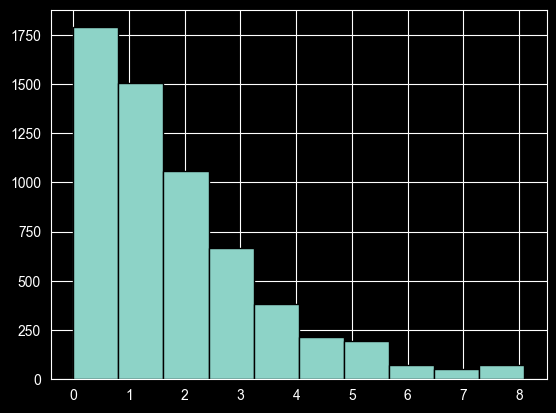

In [261]:
plt.hist(X_train['prob_age'], edgecolor='k')
plt.show()

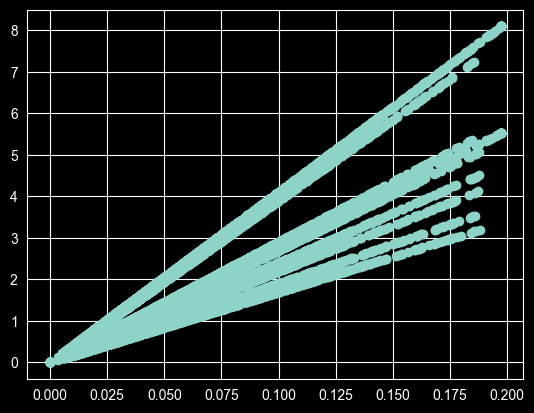

In [262]:
plt.scatter(X_train['X4'],X_train['prob_age'])
plt.show()

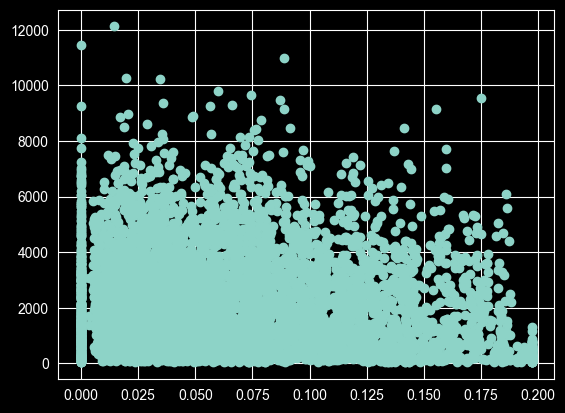

In [263]:
plt.scatter(df['X4'],df['Y'])
plt.show()

### Checking Feature Importance

In [264]:
df_train = X_train.copy()
df_train['y'] = y_train

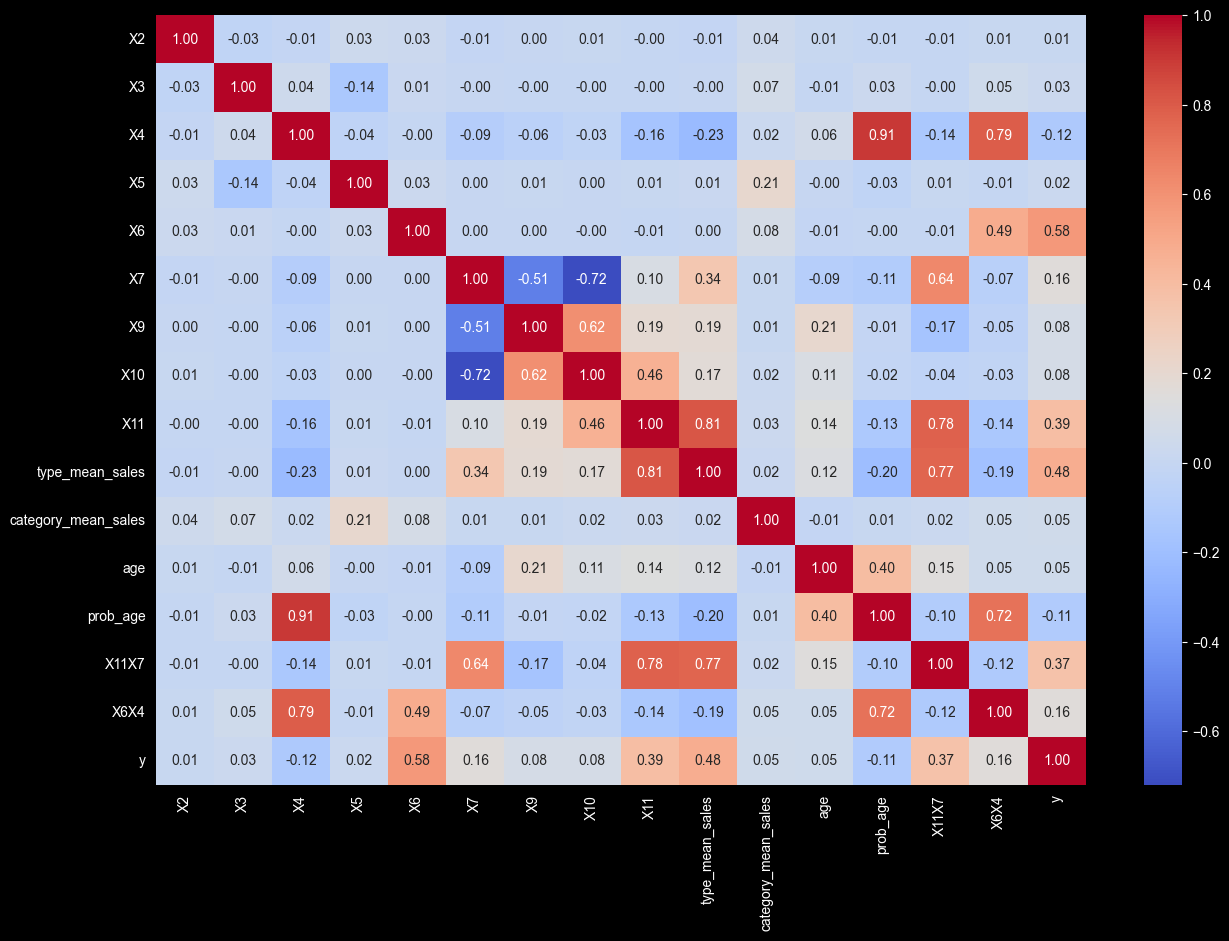

In [265]:
plt.figure(figsize=(15,10))
sns.heatmap(df_train.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [266]:
#Made it to test my models' accuracy on it as I didn't have testing data

from sklearn.model_selection import train_test_split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(df_train.drop(columns=['y']),df_train['y'], test_size=0.3, random_state=42)

In [267]:
param_grid_rf = {
  'max_depth': list(np.arange(1,30,1)),
  'min_samples_split': [2,3,4] + list(np.arange(5,50,1))
}
grid_tree = GridSearchCV(DecisionTreeRegressor(), param_grid_rf, cv=5)
grid_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [np.int64(1), np.int64(2), ...], 'min_samples_split': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [268]:
tree = grid_tree.best_estimator_
tree.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

                feature  importance
4                    X6    0.559753
13                X11X7    0.301783
9       type_mean_sales    0.099806
8                   X11    0.023314
10  category_mean_sales    0.008931
11                  age    0.003354
14                 X6X4    0.001822
12             prob_age    0.001103
0                    X2    0.000076
2                    X4    0.000054
3                    X5    0.000003
6                    X9    0.000000
5                    X7    0.000000
1                    X3    0.000000
7                   X10    0.000000


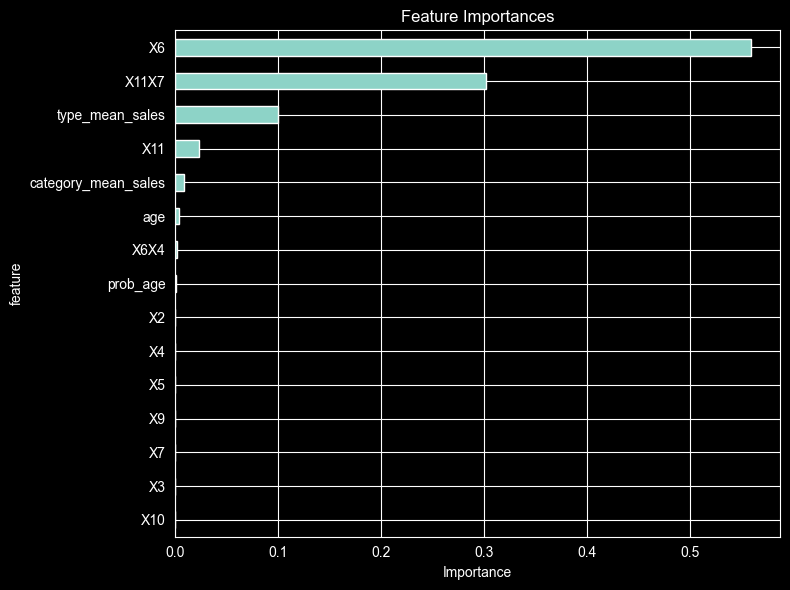

In [269]:
importances.plot(x='feature', y='importance', kind='barh', figsize=(8, 6), legend=False)
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Trying Different Models

In [270]:
Predictions_scores = {}

#### Random Forest

In [271]:
param_dist = {
    'n_estimators':      randint(50, 500),
    'max_depth':         randint(1, 15),
    'min_samples_split': randint(2, 150),
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf, param_dist,
    n_iter=200,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train_c, y_train_c)

Predictions_scores['RF R2 : '] = rf_search.score(X_test_c, y_test_c)

print("Best params: ", rf_search.best_params_)
print("Best CV R2:  ", rf_search.best_score_)
print("Test R2:     ", Predictions_scores['RF R2 : '])

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params:  {'max_depth': 6, 'min_samples_split': 94, 'n_estimators': 308}
Best CV R2:   0.5966631634945658
Test R2:      0.5933991092461124


#### Gradient Boosting

In [272]:
param_dist = {
    'n_estimators':      randint(50, 500),
    'max_depth':         np.arange(1, 20,1),
    'min_samples_split': randint(2, 150),
}

GB = GradientBoostingRegressor(random_state=42)

GB_search = RandomizedSearchCV(
    GB, param_dist,
    n_iter=200,
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

GB_search.fit(X_train_c, y_train_c)

Predictions_scores['GB R2 : '] = GB_search.score(X_test_c, y_test_c)

print("Best params: ", GB_search.best_params_)
print("Best CV R2:  ", GB_search.best_score_)
print("Test R2:     ", Predictions_scores['GB R2 : '])

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params:  {'max_depth': np.int64(2), 'min_samples_split': 6, 'n_estimators': 78}
Best CV R2:   0.5936791480672976
Test R2:      0.59331291594801


#### XG Boost

In [273]:
xgb_boost = xgb.XGBRegressor(
    tree_method='hist',
    device='cpu',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':       randint(50, 500),
    'max_depth':          randint(2, 10),
    'learning_rate':      uniform(0.01, 0.3),
    'subsample':          uniform(0.6, 0.4),
    'colsample_bytree':   uniform(0.6, 0.4),
    'min_child_weight':   randint(1, 10),
    'gamma':              uniform(0, 0.5),
}

xgb_search = RandomizedSearchCV(
    xgb_boost, param_dist,
    n_iter=200,
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_train_c, y_train_c)

Predictions_scores['XGB R2 : '] = xgb_search.score(X_test_c, y_test_c)

print("Best params: ", xgb_search.best_params_)
print("Best CV R2:  ", xgb_search.best_score_)
print("Test R2:     ", Predictions_scores['XGB R2 : '])

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best params:  {'colsample_bytree': np.float64(0.938563139725823), 'gamma': np.float64(0.4776181563617395), 'learning_rate': np.float64(0.056401642264970867), 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 122, 'subsample': np.float64(0.6300551126943235)}
Best CV R2:   0.5938446112388419
Test R2:      0.5906633146063187


#### LG Boost

In [274]:
param_dist = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'learning_rate':     np.linspace(0.01, 0.2, 20),
    'max_depth':         [-1, 3, 4, 5, 6, 7],
    'num_leaves':        [15, 31, 50, 63, 80, 100],
    'min_child_samples': [10, 20, 30, 50],
    'subsample':         np.linspace(0.5, 1.0, 10),
    'colsample_bytree':  np.linspace(0.5, 1.0, 10),
    'reg_alpha':         [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda':        [0, 0.01, 0.1, 0.5, 1.0],
}

LGB = lgb.LGBMRegressor(objective='regression', random_state=42, n_jobs=-1, verbose=-1)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lgb_search = RandomizedSearchCV(
    estimator=LGB,
    param_distributions=param_dist,
    n_iter=200,
    scoring='r2',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgb_search.fit(X_train_c, y_train_c)

Predictions_scores['LGB R2 : '] = lgb_search.score(X_test_c, y_test_c)

print("Best Params: ", lgb_search.best_params_)
print("Best CV R2:  ",lgb_search.best_score_)
print("Test R2:     ",Predictions_scores['LGB R2 : '])

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best Params:  {'subsample': np.float64(0.8888888888888888), 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 80, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': np.float64(0.05), 'colsample_bytree': np.float64(0.8333333333333333)}
Best CV R2:   0.5980980778555827
Test R2:      0.5931104621736343


#### Cat Boost

In [182]:
param_dist = {
    'iterations':        [100, 200, 300, 500],
    'learning_rate':     np.linspace(0.01, 0.2, 20),
    'depth':             [3, 4, 5, 6, 7, 8],
    'l2_leaf_reg':       [1, 3, 5, 7, 9],
    'subsample':         np.linspace(0.5, 1.0, 10),
    'colsample_bylevel': np.linspace(0.5, 1.0, 10),
    'min_data_in_leaf':  [1, 5, 10, 20, 50],
}

cat_model = CatBoostRegressor(
    random_seed=42,
    verbose=0,
    task_type='CPU'
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=200,
    scoring='r2',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train_c, y_train_c)

Predictions_scores['CAT R2 : '] = cat_search.score(X_test_c, y_test_c)

print("Best Params:  ", cat_search.best_params_)
print(f"Best CV R2:  ",cat_search.best_score_)
print(f"Test R2:     ",Predictions_scores['CAT R2 : '])

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best Params:   {'subsample': np.float64(0.7777777777777778), 'min_data_in_leaf': 20, 'learning_rate': np.float64(0.06999999999999999), 'l2_leaf_reg': 5, 'iterations': 100, 'depth': 6, 'colsample_bylevel': np.float64(0.7222222222222222)}
Best CV R2:   0.6023735409440465
Test R2:      0.5877788563772924


### Comparing Scores

In [278]:
for name, pred in Predictions_scores.items():
    print(name,pred)

RF R2 :  0.5933991092461124
GB R2 :  0.59331291594801
XGB R2 :  0.5906633146063187
LGB R2 :  0.5931104621736343


#### Generating Submission

In [280]:
Rf = rf_search.best_estimator_
Rf.fit(X_train, y_train)
y_pred = Rf.predict(X_test)

In [275]:
sample = pd.read_csv('sample_submission.csv')
sample.head()

,row_id,Y
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [281]:
submission = pd.DataFrame({
    'row_id': pd.read_csv("sample_submission.csv")['row_id'],
    'Y': y_pred
})

submission.to_csv("submission.csv", index=False)

In [282]:
submission.head()

,row_id,Y
0,0,5975.677836
1,1,1354.141851
2,2,525.145144
3,3,1026.039776
4,4,1702.971841
